# NEPSE Next-Day Direction Predictor — EDA and Modeling

**Problem:** Retail investors on the Nepal Stock Exchange (NEPSE) often trade on
rumor and herd behavior. This notebook explores whether a defendant... *(typo
guard — meant: whether a stock's* **next-day price direction** *(up or down)*
can be predicted from its own recent price and volume history — technical
indicators only, no news or fundamentals — and honestly evaluates whether that
signal is strong enough to be useful.

**Data:** Daily OHLCV price data for 236 NEPSE-listed companies (those with at
least ~3 years of trading history), sourced from a public, auto-updating
GitHub dataset (`Aabishkar2/nepse-data`), covering 1995–2026.

In [2]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from features import FEATURE_COLUMNS

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [3]:
raw_panel = pd.read_parquet("../data/panel_raw.parquet")
feat = pd.read_parquet("../data/panel_features.parquet")

print(f"Raw panel: {len(raw_panel):,} rows, {raw_panel['ticker'].nunique()} companies")
print(f"Feature panel: {len(feat):,} rows, {feat['ticker'].nunique()} companies")
print(f"Date range: {feat['published_date'].min().date()} to {feat['published_date'].max().date()}")

Raw panel: 445,013 rows, 236 companies
Feature panel: 439,328 rows, 236 companies
Date range: 1995-12-04 to 2026-07-29


## 1. Dataset Overview

How much history does each company have, and how many companies were listed
over time?

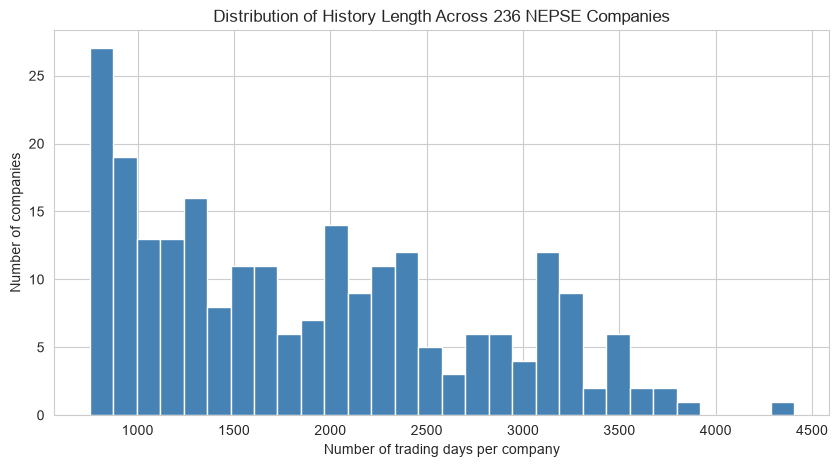

count     236.000000
mean     1885.648305
std       865.621228
min       751.000000
25%      1122.000000
50%      1725.000000
75%      2437.000000
max      4407.000000
dtype: float64


In [4]:
history_length = raw_panel.groupby("ticker").size().sort_values(ascending=False)

fig, ax = plt.subplots()
ax.hist(history_length, bins=30, color="steelblue", edgecolor="white")
ax.set_xlabel("Number of trading days per company")
ax.set_ylabel("Number of companies")
ax.set_title("Distribution of History Length Across 236 NEPSE Companies")
plt.show()

print(history_length.describe())

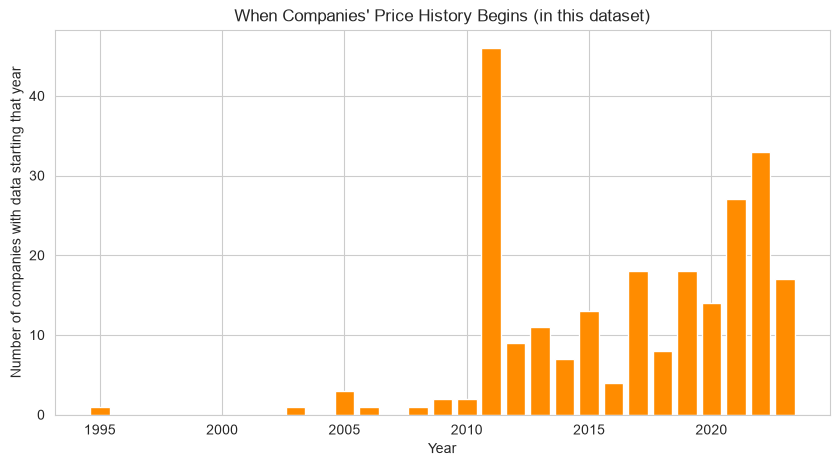

In [5]:
first_dates = raw_panel.groupby("ticker")["published_date"].min()
listings_per_year = first_dates.dt.year.value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(listings_per_year.index, listings_per_year.values, color="darkorange")
ax.set_xlabel("Year")
ax.set_ylabel("Number of companies with data starting that year")
ax.set_title("When Companies' Price History Begins (in this dataset)")
plt.show()

## 2. What Does NEPSE Price Data Actually Look Like?

A look at a couple of individual companies' price history, including the
corporate-action price jumps that needed special handling.

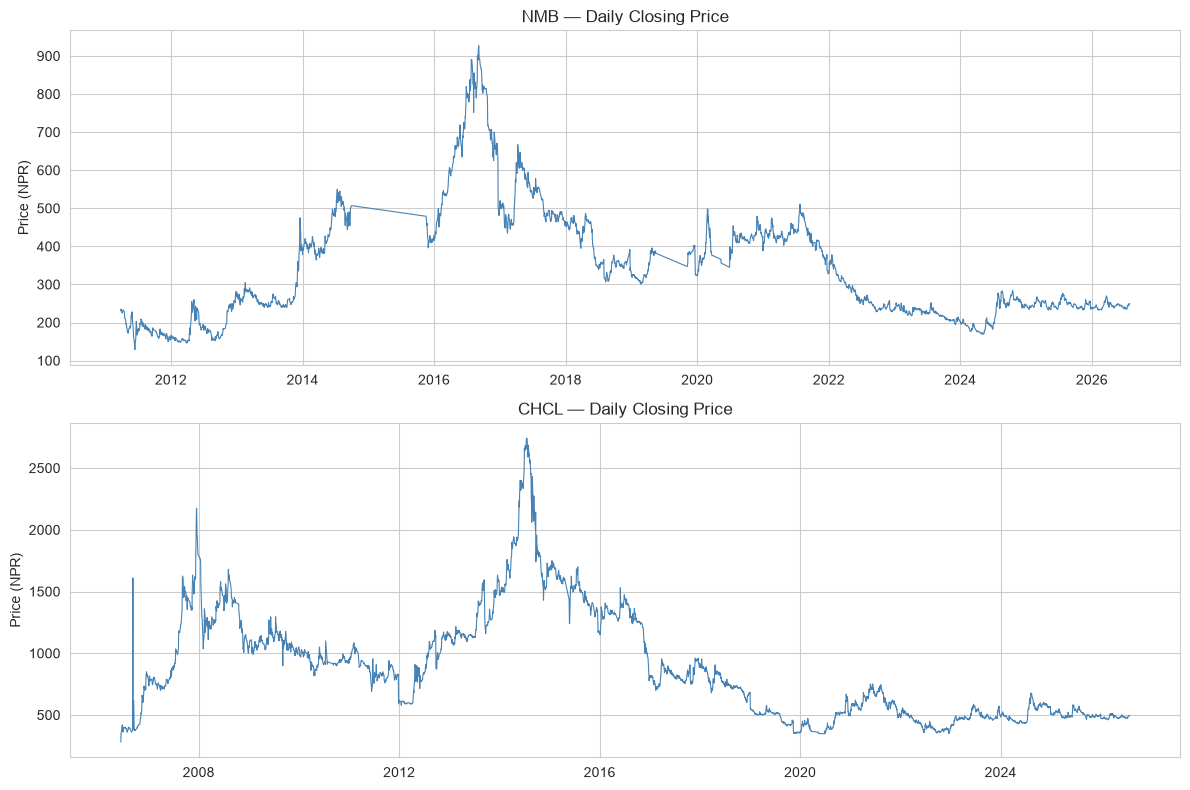

In [6]:
example_tickers = ["NMB", "CHCL"]

fig, axes = plt.subplots(len(example_tickers), 1, figsize=(12, 8))

for ax, ticker in zip(axes, example_tickers):
    company_data = raw_panel[raw_panel["ticker"] == ticker]
    ax.plot(company_data["published_date"], company_data["close"], color="steelblue", linewidth=0.8)
    ax.set_title(f"{ticker} — Daily Closing Price")
    ax.set_ylabel("Price (NPR)")

plt.tight_layout()
plt.show()

In [7]:
raw_panel["daily_return"] = raw_panel.groupby("ticker")["close"].pct_change()
extreme_moves = raw_panel[raw_panel["daily_return"].abs() > 0.25].sort_values("daily_return", ascending=False)

print(f"Number of single-day moves greater than 25%: {len(extreme_moves)}")
print(f"\nOut of {len(raw_panel):,} total rows ({len(extreme_moves) / len(raw_panel) * 100:.3f}% of all rows)")
extreme_moves[["ticker", "published_date", "close", "daily_return"]].head(10)

Number of single-day moves greater than 25%: 211

Out of 445,013 total rows (0.047% of all rows)


,ticker,published_date,close,daily_return
416057,STC,2017-11-26,265.0,inf
399012,SMATA,2018-03-29,590.0,inf
214647,MPFL,2017-08-13,129.0,inf
329774,RLFL,2017-07-23,220.0,inf
50256,CHCL,2006-09-09,1610.0,3.304813
79099,EDBL,2009-08-09,1000.0,2.267974
35502,BPCL,2006-09-09,1785.0,2.187500
64720,CZBIL,2009-09-06,668.0,1.360424
400682,SMB,2018-06-13,613.0,0.630319
50261,CHCL,2006-09-14,616.0,0.587629


## 3. Target Balance — How Often Does NEPSE Go Up vs. Down?

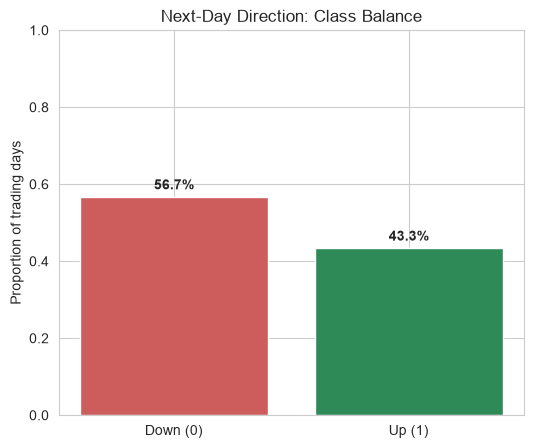

In [8]:
target_counts = feat["target_up"].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(["Down (0)", "Up (1)"], target_counts.values, color=["indianred", "seagreen"])
ax.set_ylabel("Proportion of trading days")
ax.set_title("Next-Day Direction: Class Balance")
ax.set_ylim(0, 1)

for bar, value in zip(bars, target_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f"{value:.1%}", ha="center", fontweight="bold")

plt.show()

The classes are mildly imbalanced (~57% down-days vs. ~43% up-days). This
means a naive "always predict down" strategy would already achieve ~56%
accuracy without learning anything — which is exactly why we evaluate our
models using ROC-AUC and F1, not accuracy alone, and why we specifically
built a majority-class baseline to compare against.

## 4. Feature Distributions

A look at a few of the 14 engineered features, to sanity-check they look
reasonable (no leftover extreme outliers, sensible ranges) before modeling.

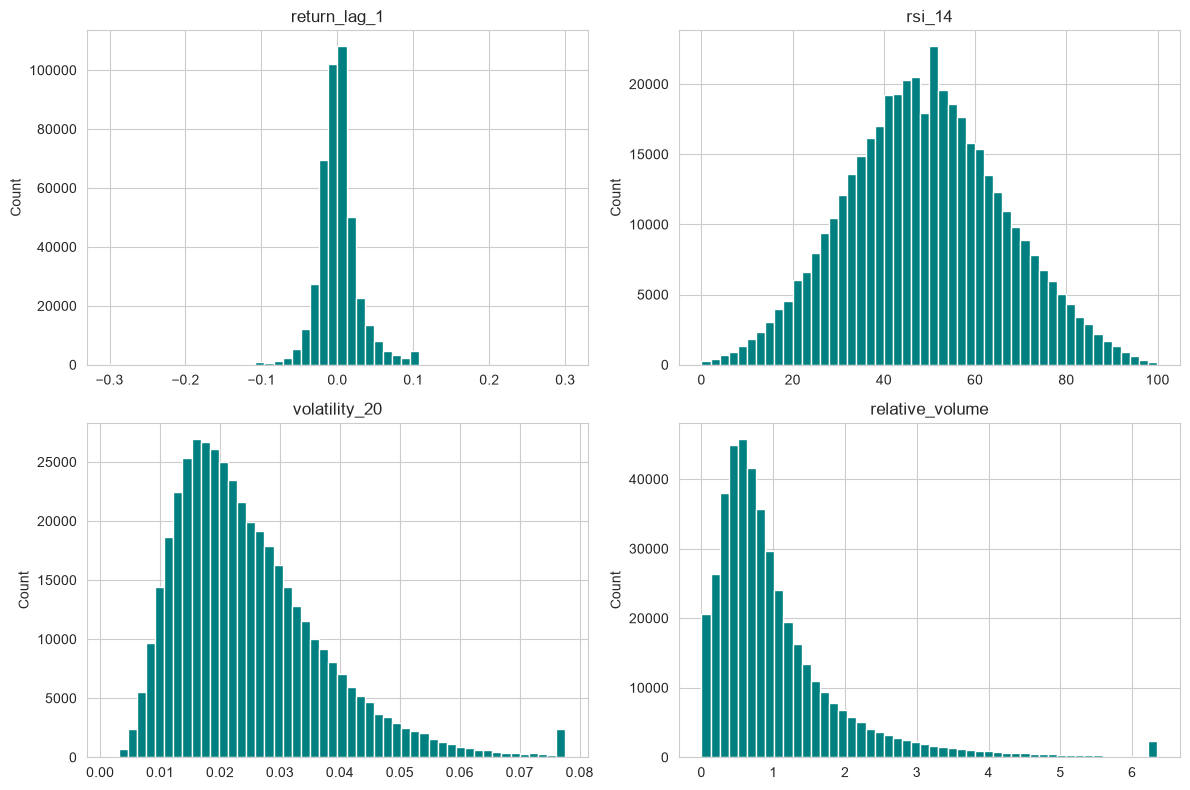

In [9]:
features_to_plot = ["return_lag_1", "rsi_14", "volatility_20", "relative_volume"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, features_to_plot):
    ax.hist(feat[col].dropna(), bins=50, color="teal", edgecolor="white")
    ax.set_title(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

All four features show sensible, expected shapes. Note the small "spike" at
the far right edge of `volatility_20` and `relative_volume` — this is the
visible signature of winsorizing: extreme values were capped at the 99.5th
percentile rather than removed, so they pile up at that cutoff instead of
trailing off naturally. This is expected and intentional, not a data error.

## 5. Model Results

Comparing two baselines (majority-class, naive momentum) against two trained
models (Logistic Regression, Random Forest), using a strict time-based split:
trained on data before 2025-01-01, tested on 2025-01-01 onward — data the
models never saw during training.

In [11]:
import json

with open("../models/metrics.json") as f:
    metrics_data = json.load(f)

results_df = pd.DataFrame(metrics_data["results"])
results_df = results_df[["model", "accuracy", "precision", "recall", "f1", "roc_auc"]]
results_df

,model,accuracy,precision,recall,f1,roc_auc
0,Majority-class baseline,0.562579,0.000000,0.000000,0.000000,NaN
1,Naive momentum (repeat today),0.502076,0.431093,0.432668,0.431879,NaN
2,Logistic Regression,0.506907,0.436515,0.437558,0.437036,0.500943
3,Random Forest,0.519929,0.445864,0.401519,0.422531,0.512936


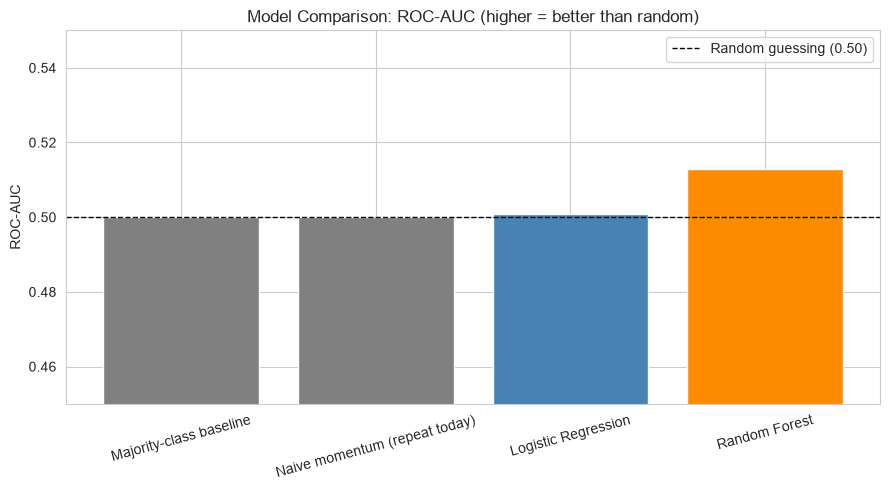

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["gray", "gray", "steelblue", "darkorange"]
bars = ax.bar(results_df["model"], results_df["roc_auc"].fillna(0.5), color=colors)

ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="Random guessing (0.50)")
ax.set_ylabel("ROC-AUC")
ax.set_title("Model Comparison: ROC-AUC (higher = better than random)")
ax.set_ylim(0.45, 0.55)
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

All four approaches sit close to the 0.50 "random guessing" line. The
majority-class baseline has the highest raw accuracy (~56%) but 0 precision
and 0 recall — it never predicts "up" at all, making it accurate-looking but
practically useless. Random Forest achieves the best ROC-AUC (~0.513),
narrowly ahead of Logistic Regression (~0.501) — a small, genuine edge over
random guessing, but far too weak to be a reliable trading signal on its own.

## 6. Error Analysis

Where does the model actually go wrong, and does its performance vary by
company or by market volatility?

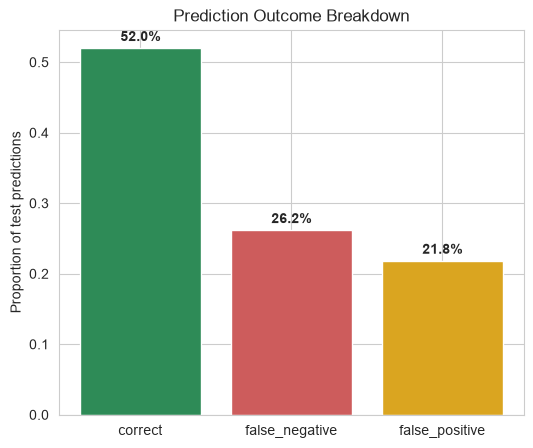

In [13]:
import joblib

model = joblib.load("../models/direction_model.joblib")

test_data = feat[feat["published_date"] >= pd.Timestamp("2025-01-01")].copy()
test_data["predicted_up"] = model.predict(test_data[FEATURE_COLUMNS])

def label_error(row):
    if row["target_up"] == row["predicted_up"]:
        return "correct"
    elif row["predicted_up"] == 1 and row["target_up"] == 0:
        return "false_positive"
    else:
        return "false_negative"

test_data["error_type"] = test_data.apply(label_error, axis=1)
error_breakdown = test_data["error_type"].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(error_breakdown.index, error_breakdown.values, color=["seagreen", "indianred", "goldenrod"])
ax.set_ylabel("Proportion of test predictions")
ax.set_title("Prediction Outcome Breakdown")
for i, v in enumerate(error_breakdown.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontweight="bold")
plt.show()

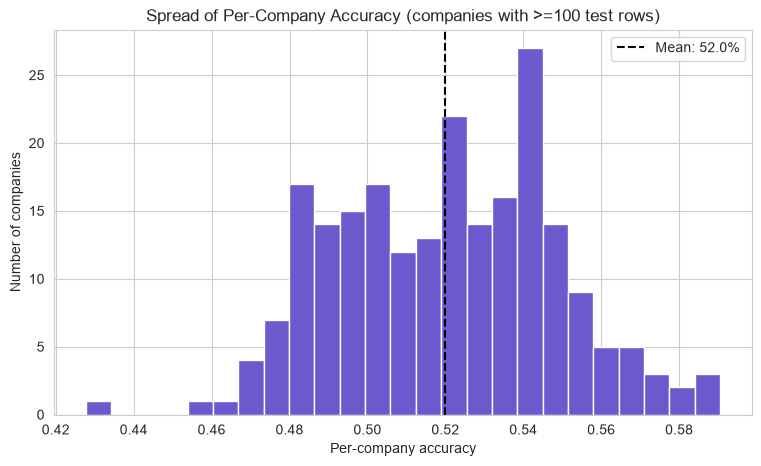

Standard deviation across companies: 0.0282


In [14]:
per_ticker = (
    test_data.groupby("ticker")
    .apply(lambda g: pd.Series({
        "n_rows": len(g),
        "accuracy": (g["target_up"] == g["predicted_up"]).mean(),
    }), include_groups=False)
)
per_ticker = per_ticker[per_ticker["n_rows"] >= 100]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(per_ticker["accuracy"], bins=25, color="slateblue", edgecolor="white")
ax.axvline(per_ticker["accuracy"].mean(), color="black", linestyle="--", label=f"Mean: {per_ticker['accuracy'].mean():.1%}")
ax.set_xlabel("Per-company accuracy")
ax.set_ylabel("Number of companies")
ax.set_title("Spread of Per-Company Accuracy (companies with >=100 test rows)")
ax.legend()
plt.show()

print(f"Standard deviation across companies: {per_ticker['accuracy'].std():.4f}")

The per-company accuracy spread ranges roughly from the low 40s% to the high
50s%, with what appears to be one smooth, continuous distribution rather than
distinct clusters — consistent with **sampling noise**, not a real difference
in model skill between companies. With ~236 companies and roughly 360 test
rows each, this much spread is expected even if the model's true skill is
identical across every company (a version of the "multiple comparisons"
problem — when you look at many groups, some will look unusually good or bad
by chance alone). We do not conclude the model works meaningfully better on
specific companies from this data.

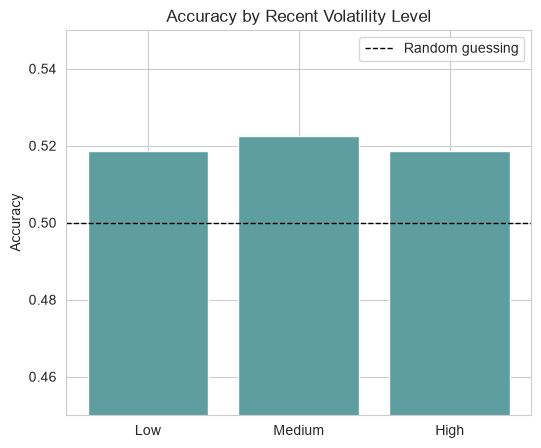

In [15]:
test_data["volatility_bucket"] = pd.qcut(test_data["volatility_20"], q=3, labels=["Low", "Medium", "High"])
accuracy_by_vol = test_data.groupby("volatility_bucket", observed=True).apply(
    lambda g: (g["target_up"] == g["predicted_up"]).mean(), include_groups=False
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(accuracy_by_vol.index, accuracy_by_vol.values, color="cadetblue")
ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="Random guessing")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by Recent Volatility Level")
ax.set_ylim(0.45, 0.55)
ax.legend()
plt.show()

Accuracy is essentially flat across low/medium/high volatility regimes
(~52% in all three) — the model does not perform meaningfully better in
calmer or choppier markets.